# Análisis de clases y características

📊 ANALIZANDO EL BALANCE DE CLASES...


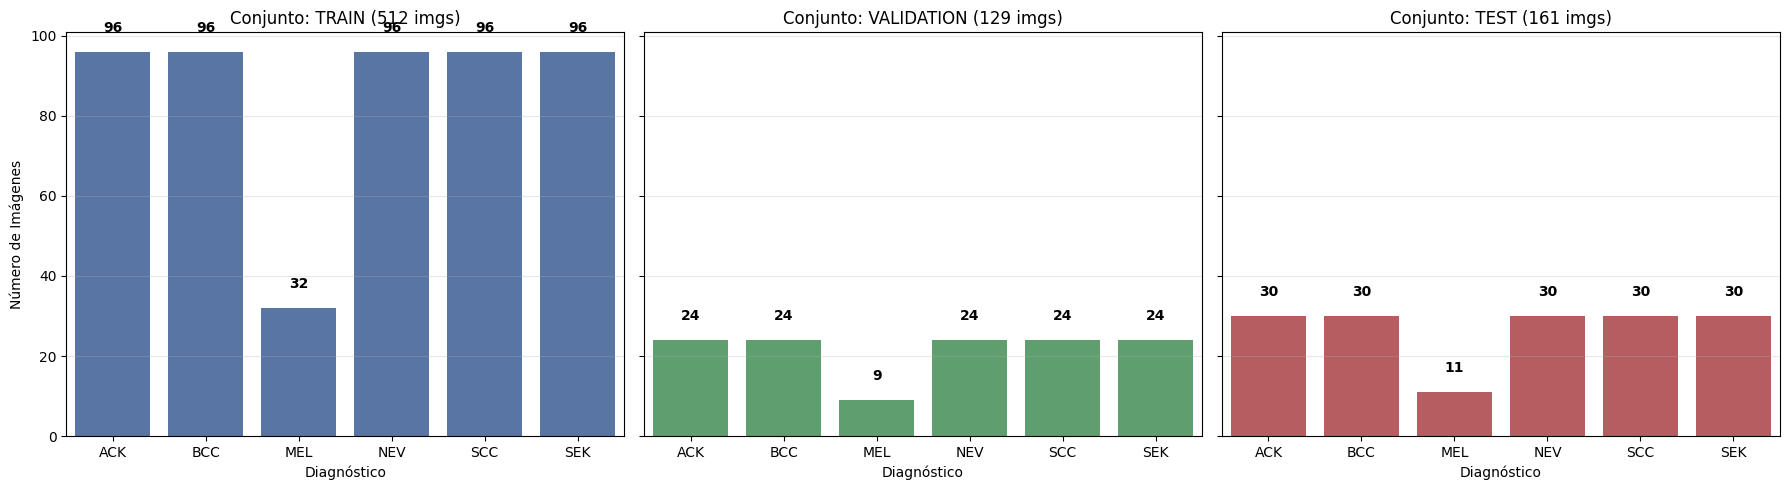


📏 ANALIZANDO DIMENSIONES DE IMÁGENES (Esto puede tardar un poco)...


100%|██████████| 802/802 [00:00<00:00, 2297.24it/s]



Resumen de Tamaños:
Medio: 890x890
Mínimo: 147x147
Máximo: 3474x3476


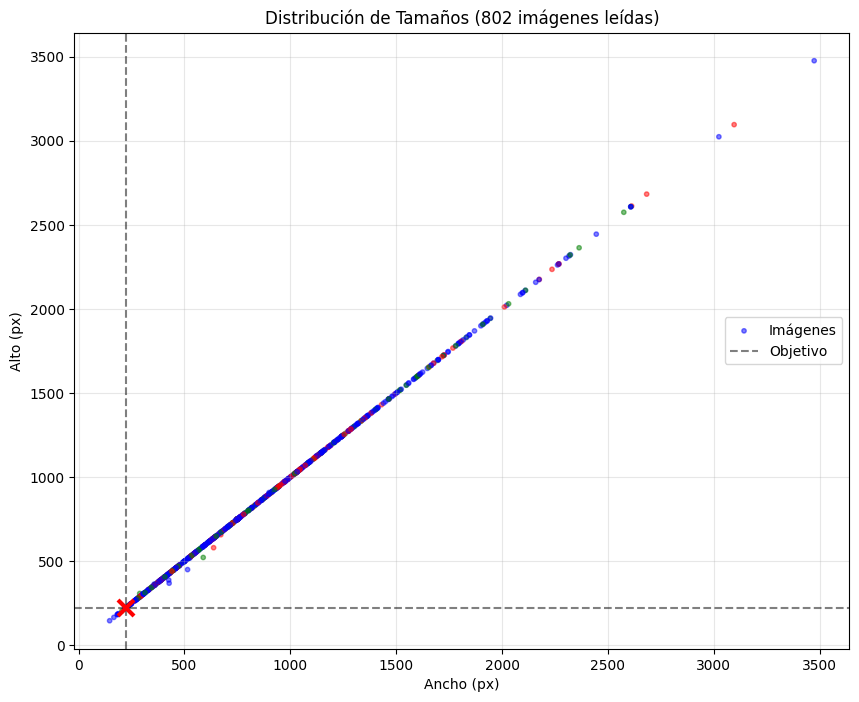

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm import tqdm # Barra de progreso

# ================= CONFIGURACIÓN =================
# Pon aquí la ruta a tu CSV y a tus imágenes
CSV_PATH = "../Datos/Diccionario.csv"
# Si ya moviste las carpetas, pon la ruta nueva. Si no, la de MULTICLASE.
# El código asume estructura: RUTA_RAIZ / CLASE / FOTO
RUTA_RAIZ = "../Datos/images/MULTICLASE/" 

# Cargar datos
df = pd.read_csv(CSV_PATH)

# ================= PARTE 1: BALANCE DE CLASES =================
print("📊 ANALIZANDO EL BALANCE DE CLASES...")

# Crear una figura con 3 sub-gráficas (Train, Val, Test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
splits = ['train', 'validation', 'test']
colores = ['#4c72b0', '#55a868', '#c44e52'] # Azul, Verde, Rojo

for i, split in enumerate(splits):
    # Filtrar datos de este split
    datos_split = df[df['conjunto_train_test_val'] == split]
    
    # Contar ocurrencias
    conteo = datos_split['diagnostic'].value_counts().sort_index()
    
    # Dibujar barras
    sns.barplot(x=conteo.index, y=conteo.values, ax=axes[i], color=colores[i])
    
    # Decoración
    axes[i].set_title(f'Conjunto: {split.upper()} ({len(datos_split)} imgs)')
    axes[i].set_xlabel('Diagnóstico')
    axes[i].grid(axis='y', alpha=0.3)
    
    # Poner el número encima de la barra
    for index, value in enumerate(conteo.values):
        axes[i].text(index, value + 5, str(value), ha='center', fontweight='bold')

axes[0].set_ylabel('Número de Imágenes')
plt.tight_layout()
plt.show()

# ================= PARTE 2: TAMAÑO DE IMÁGENES =================
print("\n📏 ANALIZANDO DIMENSIONES DE IMÁGENES (Esto puede tardar un poco)...")

anchos = []
altos = []
colores_puntos = []

# Mapeo de split a color para la gráfica
mapa_colores = {'train': 'blue', 'validation': 'green', 'test': 'red'}

# Recorremos el CSV (usamos tqdm para ver barra de progreso)
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    split = row['conjunto_train_test_val']
    clase = row['diagnostic']
    nombre = row['img_id']
    
    # Construir ruta. AJUSTA ESTO SI TUS CARPETAS TIENEN OTRA ESTRUCTURA
    # Opción A: Si usas la carpeta original MULTICLASE/CLASE/FOTO
    ruta_completa = os.path.join(RUTA_RAIZ, clase, nombre)
    
    # Opción B: Si ya moviste las carpetas a train/test/val...
    # ruta_completa = os.path.join(RUTA_RAIZ, split, clase, nombre)
    
    try:
        # Solo leemos la cabecera del archivo para no cargar toda la imagen (es rápido)
        with Image.open(ruta_completa) as img:
            w, h = img.size
            anchos.append(w)
            altos.append(h)
            colores_puntos.append(mapa_colores.get(split, 'gray'))
    except Exception as e:
        # Si falla (ej. imagen no encontrada), pasamos
        pass

# Graficar Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(anchos, altos, c=colores_puntos, alpha=0.5, s=10)

# Dibujar referencias
plt.axvline(224, color='k', linestyle='--', alpha=0.5)
plt.axhline(224, color='k', linestyle='--', alpha=0.5)
plt.plot(224, 224, 'rx', markersize=12, markeredgewidth=3, label='Objetivo 224x224')

plt.title(f"Distribución de Tamaños ({len(anchos)} imágenes leídas)")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.legend(['Imágenes', 'Objetivo'])
plt.grid(True, alpha=0.3)

# Mostrar estadísticas
print(f"\nResumen de Tamaños:")
print(f"Medio: {sum(anchos)//len(anchos)}x{sum(altos)//len(altos)}")
print(f"Mínimo: {min(anchos)}x{min(altos)}")
print(f"Máximo: {max(anchos)}x{max(altos)}")

plt.show()

Conclusiones que saco de aqui:
Dataset:
1. En el dataset está claro que MEL es el tipo de enfermedad con menos imágenes, por lo que es el que más dificultad va a tener el modelo.
2. Train 500 imágenes, validation 130 y test 160 (Split 70/15/15)
3. La cantidad de datos es baja por lo que tendremos que realizar un data augmentation

Tamaños:
1. Significa que todas las fotops tienen la misma proporción o aspect ratio
2. Podemos usar resize directamente sin usar center_crop


Acciones:
1. Vamos a usar WeightedRandomSampler para forzar al Dataloader a coger la misma cantidad de fotos de cada tipo de enfermedad
2. Usamops batch 32 por temas de memoria y 224 porque es el estándar de oro para finetuning posterior 
3. Hacemos dataugmentation exagerad, y normalizamosd como el datset imagenet qyue es con lo que se entrenaron los modelos que finetunearemos

### Carga de datos,creacdión de dataloaders, balñanceo y data augmentation

In [38]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- 1. CONFIGURACIÓN ---
RUTA_BASE = "../Datos/images/DATASET_SPLIT" # Ajusta si tu carpeta se llama distinto
BATCH_SIZE = 32 #dejamos un batch size de 32 ya quie si hacemos pruebas con Resnet560 ,VGG o efficientNet nos quedaremos sin memoria 
IMG_SIZE = 224 #estandar para trasnfer learning

# --- 2. DEFINIR LAS TRANSFORMACIONES (Aquí está el Data Augmentation) ---

# A. Para ENTRENAMIENTO (Caos controlado)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),       # 1. Tamaño base
    transforms.RandomHorizontalFlip(p=0.5),        # 2. Espejo horizontal
    transforms.RandomVerticalFlip(p=0.5),          # 3. Espejo vertical (útil en piel)
    transforms.RandomRotation(degrees=45),         # 4. Rotar +/- 45 grados
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # 5. Cambios de luz leves
    transforms.ToTensor(),                         # 6. A Tensor [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 7. Normalizar con media y desviación de ImageNet, ya que haremos trasnferlearning
])

# B. Para VAL y TEST (Limpieza total)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. CARGAR DATASETS (El Bibliotecario) ---
# ImageFolder lee las carpetas train/ACK, train/MEL...
train_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=train_transform)
val_dataset   = datasets.ImageFolder(f"{RUTA_BASE}/val", transform=val_test_transform)
test_dataset  = datasets.ImageFolder(f"{RUTA_BASE}/test", transform=val_test_transform)


# --- 4. CREAR DATALOADERS  ---


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=2,pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=2,pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=2,pin_memory=True)

### Desnormalizamos y mostramos transformaciones del data augmentation

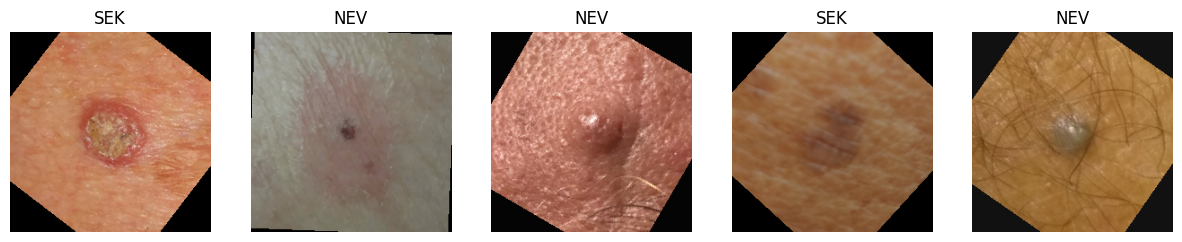

In [39]:
import matplotlib.pyplot as plt

# Sacamos un lote del train_loader (que ya tiene augmentation aplicado)
imgs, labels = next(iter(train_loader))

# Función para des-normalizar y ver la foto bien
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

# Mostramos 5 ejemplos
plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(denormalize(imgs[i]))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_training_history(historial):
    """
    Visualiza la evolución del entrenamiento.
    - Izquierda: Loss (Debe bajar).
    - Derecha: F1-Score Macro (La métrica reina, debe subir).
    """
    epochs = range(1, len(historial['train_loss']) + 1)
    
    plt.figure(figsize=(15, 6))

    # --- GRÁFICA 1: LOSS (Estabilidad) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='orange', linestyle='--', linewidth=2)
    plt.title('Evolución del Error (Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('CrossEntropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- GRÁFICA 2: F1-MACRO (Calidad Médica) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['val_f1'], label='Validation F1 (Macro)', color='green', marker='o', linewidth=2)
    plt.title('Evolución de la Calidad (F1-Score Macro)')
    plt.xlabel('Épocas')
    plt.ylabel('F1 Score (0.0 - 1.0)')
    plt.axhline(y=max(historial['val_f1']), color='r', linestyle=':', label='Mejor F1 alcanzado') # Línea de record
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score

def evaluar_rendimiento_completo(model, loader, device, classes, titulo="Set de Datos"):
    """
    Genera:
    1. Matriz de Confusión visual.
    2. Reporte detallado (Precision, Recall, F1 por clase).
    3. Métricas globales (Accuracy, Kappa).
    """
    model.eval()
    y_true = []
    y_pred = []
    
    print(f"\n🔎 Analizando métricas detalladas para: {titulo}...")
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    # --- 1. MATRIZ DE CONFUSIÓN ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusión - {titulo}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    
    # --- 2. REPORTES NUMÉRICOS ---
    print(f"\n📋 REPORTE CLÍNICO DETALLADO ({titulo})")
    print("="*70)
    # zero_division=0 evita warnings si alguna clase nunca se predice
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print("-" * 70)
    
    # Métricas Globales
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    print(f"✅ Accuracy Global:   {acc:.4f} (Cuidado, dataset desbalanceado)")
    print(f"⚖️  Cohen's Kappa:     {kappa:.4f} (Grado de acuerdo real vs azar)")
    print("="*70)

import copy
import torch.nn as nn
from sklearn.metrics import f1_score

def entrenar_modelo(model, train_loader, val_loader, criterion, optimizer, device, epochs=25, nombre_archivo="mejor_modelo.pth"):
    
    print(f"🚀 Iniciando entrenamiento por {epochs} épocas...")
    print(f"💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)")
    
    historial = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    
    best_f1 = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # --- FASE 1: ENTRENAMIENTO ---
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        
        # --- FASE 2: VALIDACIÓN ---
        model.eval()
        val_loss = 0.0
        y_true = []
        y_pred = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        
        epoch_val_loss = val_loss / len(val_loader.dataset)
        
        # CALCULAMOS F1 MACRO (La métrica que decide si guardamos)
        epoch_val_f1 = f1_score(y_true, y_pred, average='macro')
        
        # Guardar en historial
        historial['train_loss'].append(epoch_train_loss)
        historial['val_loss'].append(epoch_val_loss)
        historial['val_f1'].append(epoch_val_f1)
        
        # Mensaje de progreso
        print(f"Ep {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.3f} | Val Loss: {epoch_val_loss:.3f} | Val F1: {epoch_val_f1:.4f}", end="")
        
        # --- LÓGICA SMART SAVING ---
        if epoch_val_f1 > best_f1:
            best_f1 = epoch_val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), nombre_archivo)
            print(" 🏆 ¡Récord! Guardado.")
        else:
            print("") # Salto de línea

    print(f"\n🏁 Fin. Mejor F1 Val: {best_f1:.4f}")
    
    # IMPORTANTE: Devolvemos el modelo con los MEJORES pesos, no los últimos
    model.load_state_dict(best_model_wts)
    return model, historial

def lanzar_experimento(modelo, nombre_exp, train_loader, val_loader, test_loader, device, optimizer_ft):
    """
    Ejecuta todo el pipeline: Entrena -> Muestra Evolución -> Evalúa en Test
    """
    print(f"\n{'='*30}\n▶️ EXPERIMENTO: {nombre_exp}\n{'='*30}")
    
    # --- PASO 1: CALCULAR PESOS DE CLASE (Correctamente) ---
    # Usamos np.bincount pasando la lista como argumento
    labels_list = train_loader.dataset.targets
    class_counts = np.bincount(labels_list)
    
    # Fórmula: Peso = 1 / frecuencia
    weights = 1.0 / class_counts
    # Normalizar para que sumen el número de clases (opcional, mantiene la magnitud del gradiente)
    weights = weights / weights.sum() * len(class_counts)
    
    # Convertir a Tensor float32 y mover a GPU
    class_weights = torch.FloatTensor(weights).to(device)
    
    print(f"⚖️ Pesos de clase calculados: {class_weights.cpu().numpy()}")
    
    # --- PASO 2: CONFIGURAR LOSS Y OPTIMIZER ---
    # Definimos la Loss PONDERADA una sola vez
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Optimizador
    optimizer = optimizer_ft
    
    # --- PASO 3: ENTRENAMIENTO ---
    modelo_entrenado, historial = entrenar_modelo(
        modelo, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        device, 
        epochs=25, 
        nombre_archivo=f"{nombre_exp}_best.pth"
    )
    
    # --- PASO 4: VISUALIZACIÓN ---
    print(f"\n📈 Visualizando aprendizaje de: {nombre_exp}")
    plot_training_history(historial)
    
    # --- PASO 5: TEST FINAL ---
    print(f"\n🎯 Resultados finales en TEST SET (Datos nunca vistos)")
    evaluar_rendimiento_completo(
        modelo_entrenado, 
        test_loader, 
        device, 
        train_loader.dataset.classes, 
        titulo=f"TEST - {nombre_exp}"
    )
    
    return modelo_entrenado

Usando device: cuda

▶️ EXPERIMENTO: ResNet18_Baseline
⚖️ Pesos de clase calculados: [0.75 0.75 2.25 0.75 0.75 0.75]
🚀 Iniciando entrenamiento por 25 épocas...
💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)
Ep 1/25 | Train Loss: 1.815 | Val Loss: 1.481 | Val F1: 0.3464 🏆 ¡Récord! Guardado.
Ep 2/25 | Train Loss: 1.396 | Val Loss: 1.317 | Val F1: 0.4141 🏆 ¡Récord! Guardado.
Ep 3/25 | Train Loss: 1.133 | Val Loss: 1.209 | Val F1: 0.5201 🏆 ¡Récord! Guardado.
Ep 4/25 | Train Loss: 0.986 | Val Loss: 1.168 | Val F1: 0.5198
Ep 5/25 | Train Loss: 0.858 | Val Loss: 1.237 | Val F1: 0.5256 🏆 ¡Récord! Guardado.
Ep 6/25 | Train Loss: 0.814 | Val Loss: 1.234 | Val F1: 0.4787
Ep 7/25 | Train Loss: 0.751 | Val Loss: 1.239 | Val F1: 0.5369 🏆 ¡Récord! Guardado.
Ep 8/25 | Train Loss: 0.702 | Val Loss: 1.257 | Val F1: 0.5063
Ep 9/25 | Train Loss: 0.639 | Val Loss: 1.284 | Val F1: 0.5252
Ep 10/25 | Train Loss: 0.600 | Val Loss: 1.312 | Val F1: 0.5426 🏆 ¡Récord! Guardado.
Ep 11/25 | Train Loss

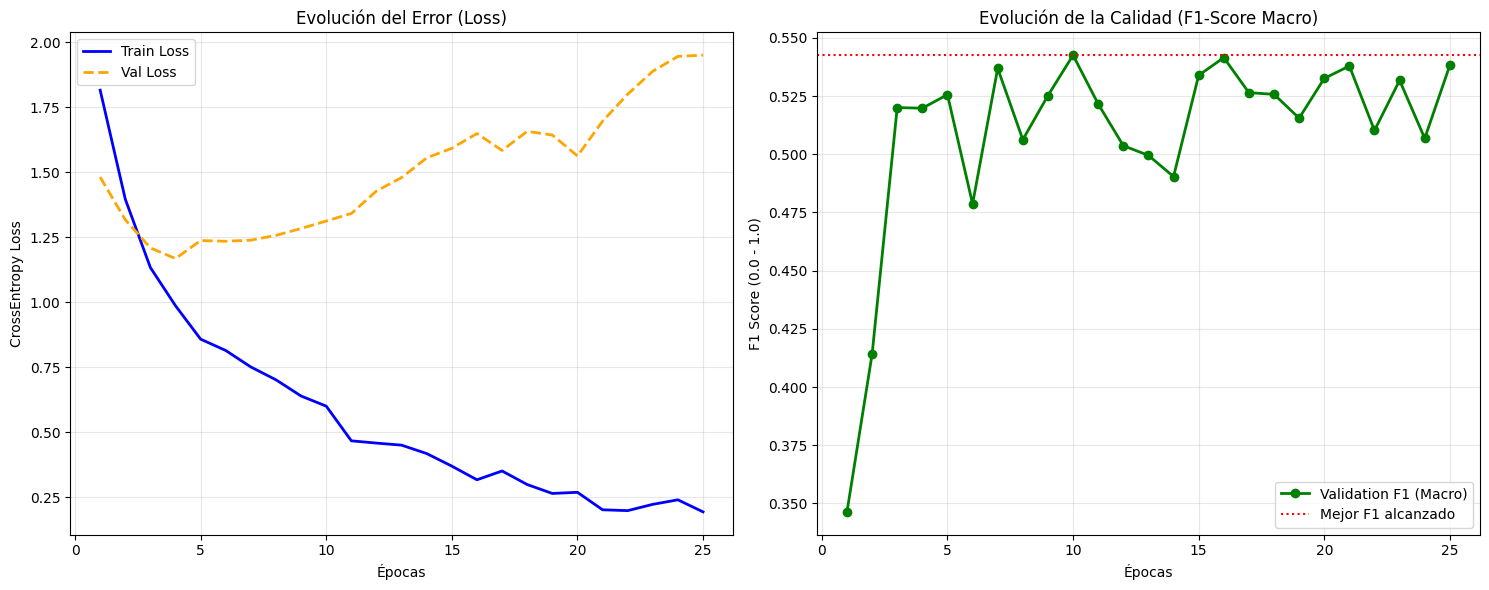


🎯 Resultados finales en TEST SET (Datos nunca vistos)

🔎 Analizando métricas detalladas para: TEST - ResNet18_Baseline...


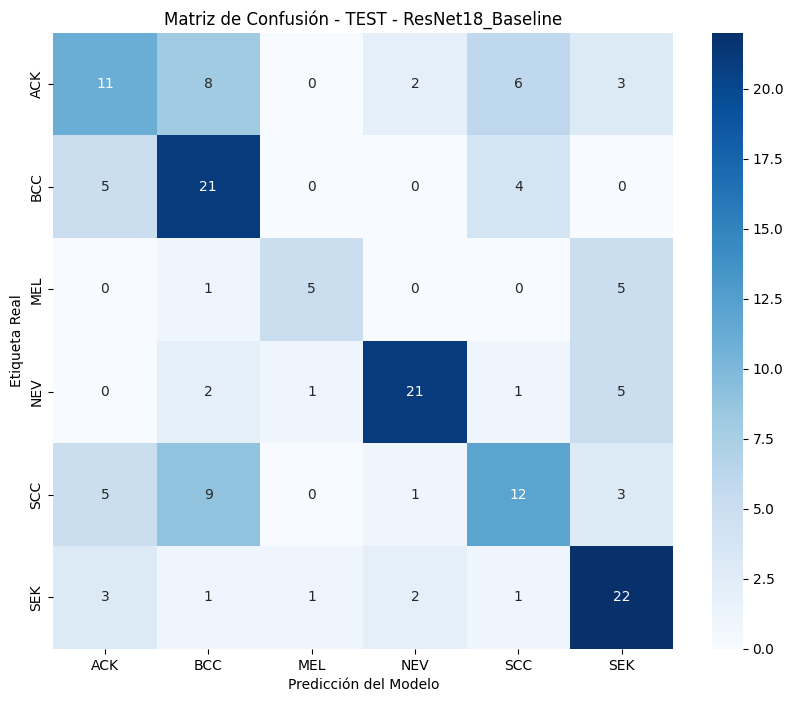


📋 REPORTE CLÍNICO DETALLADO (TEST - ResNet18_Baseline)
              precision    recall  f1-score   support

         ACK       0.46      0.37      0.41        30
         BCC       0.50      0.70      0.58        30
         MEL       0.71      0.45      0.56        11
         NEV       0.81      0.70      0.75        30
         SCC       0.50      0.40      0.44        30
         SEK       0.58      0.73      0.65        30

    accuracy                           0.57       161
   macro avg       0.59      0.56      0.56       161
weighted avg       0.58      0.57      0.57       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.5714 (Cuidado, dataset desbalanceado)
⚖️  Cohen's Kappa:     0.4766 (Grado de acuerdo real vs azar)


In [30]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# 1. Cargar ResNet18 (usamos pesos pre-entrenados para convergencia más rápida)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# 2. ESTRATEGIA: CONGELAR PRIMERO, DESCONGELAR LO IMPORTANTE
# Paso A: Congelar todo (Base sólida)
for param in model.parameters():
    param.requires_grad = False

# Paso B: DESCONGELAR el último bloque convolucional (Layer 4)
# Aquí es donde la red aprende formas complejas. Le permitimos adaptarse al cáncer.
for param in model.layer4.parameters():
    param.requires_grad = True

# 2. Adaptar la "cabeza" (última capa lineal) a tu número de clases
# 'fc' es el nombre de la capa final en las ResNets
num_ftrs = model.fc.in_features
num_classes = len(train_loader.dataset.classes)
model.fc = nn.Sequential(
    nn.Dropout(0.5), # Apaga el 50% de las neuronas aleatoriamente
    nn.Linear(num_ftrs, num_classes)
)

# 3. Mover a GPU
model = model.to(device)

# 4. OPTIMIZADOR CON "VELOCIDADES DIFERENCIALES" (Clave del éxito)
# - La cabeza (fc) es nueva y tonta: necesita ir rápido (1e-3)
# - El Layer4 ya sabe mucho: necesita ir despacio para no romperse (1e-4)
optimizer_ft = optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': 1e-4}, # Ajuste fino
    {'params': model.fc.parameters(), 'lr': 1e-3}      # Aprendizaje bruto
], weight_decay=0.01)

# 4. 🚀 LANZAR EXPERIMENTO
# Esto llamará internamente a entrenar_modelo, plot_training_history y evaluar_rendimiento_completo
model_entrenado = lanzar_experimento(
    modelo=model,
    nombre_exp="ResNet18_Baseline",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    optimizer_ft=optimizer_ft
)

Usando device: cuda

▶️ EXPERIMENTO: EfficientNetB0_FineTuning
⚖️ Pesos de clase calculados: [0.75 0.75 2.25 0.75 0.75 0.75]
🚀 Iniciando entrenamiento por 25 épocas...
💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)
Ep 1/25 | Train Loss: 1.770 | Val Loss: 1.680 | Val F1: 0.2833 🏆 ¡Récord! Guardado.
Ep 2/25 | Train Loss: 1.596 | Val Loss: 1.581 | Val F1: 0.3980 🏆 ¡Récord! Guardado.
Ep 3/25 | Train Loss: 1.480 | Val Loss: 1.516 | Val F1: 0.4051 🏆 ¡Récord! Guardado.
Ep 4/25 | Train Loss: 1.383 | Val Loss: 1.460 | Val F1: 0.4149 🏆 ¡Récord! Guardado.
Ep 5/25 | Train Loss: 1.320 | Val Loss: 1.418 | Val F1: 0.4376 🏆 ¡Récord! Guardado.
Ep 6/25 | Train Loss: 1.302 | Val Loss: 1.388 | Val F1: 0.4597 🏆 ¡Récord! Guardado.
Ep 7/25 | Train Loss: 1.259 | Val Loss: 1.358 | Val F1: 0.4652 🏆 ¡Récord! Guardado.
Ep 8/25 | Train Loss: 1.227 | Val Loss: 1.346 | Val F1: 0.4614
Ep 9/25 | Train Loss: 1.171 | Val Loss: 1.340 | Val F1: 0.4591
Ep 10/25 | Train Loss: 1.160 | Val Loss: 1.313 | Val F1:

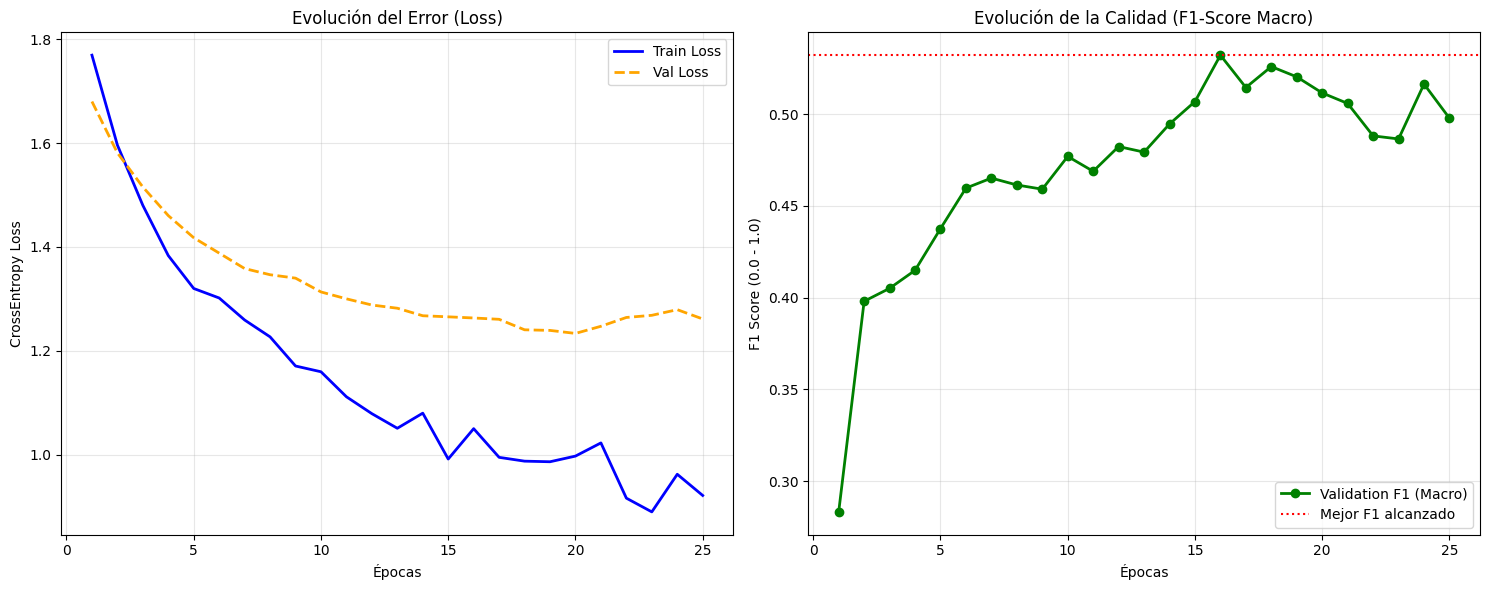


🎯 Resultados finales en TEST SET (Datos nunca vistos)

🔎 Analizando métricas detalladas para: TEST - EfficientNetB0_FineTuning...


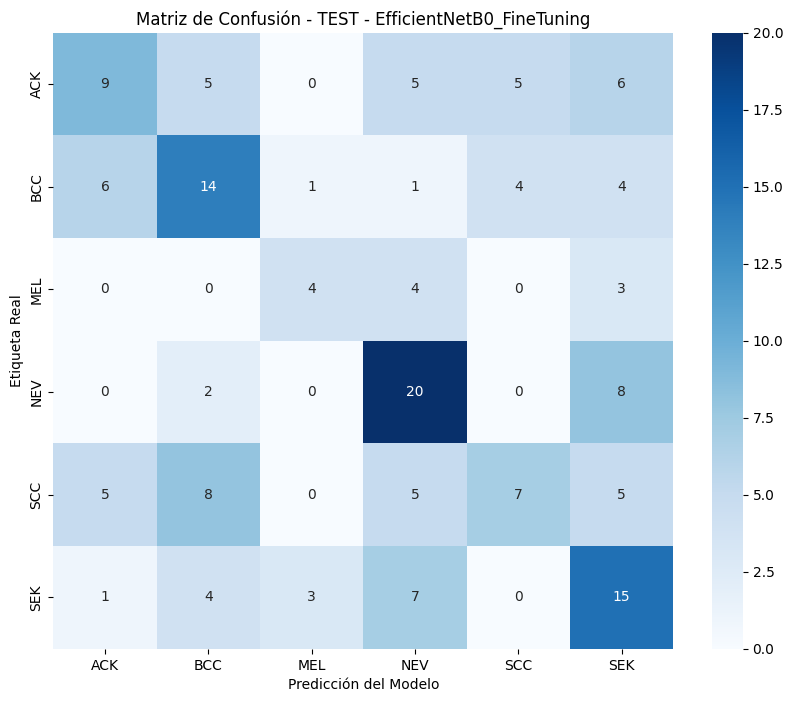


📋 REPORTE CLÍNICO DETALLADO (TEST - EfficientNetB0_FineTuning)
              precision    recall  f1-score   support

         ACK       0.43      0.30      0.35        30
         BCC       0.42      0.47      0.44        30
         MEL       0.50      0.36      0.42        11
         NEV       0.48      0.67      0.56        30
         SCC       0.44      0.23      0.30        30
         SEK       0.37      0.50      0.42        30

    accuracy                           0.43       161
   macro avg       0.44      0.42      0.42       161
weighted avg       0.43      0.43      0.42       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.4286 (Cuidado, dataset desbalanceado)
⚖️  Cohen's Kappa:     0.3027 (Grado de acuerdo real vs azar)


In [36]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# 1. Cargar EfficientNet-B0 (Pesos pre-entrenados por defecto)
# Nota: EfficientNet se beneficia mucho de los pesos V2 si están disponibles, pero usamos DEFAULT por seguridad
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# 2. ESTRATEGIA: CONGELAR PRIMERO, DESCONGELAR LO IMPORTANTE
# Paso A: Congelar todo (Base sólida)
for param in model.parameters():
    param.requires_grad = False

# Paso B: DESCONGELAR el último bloque convolucional
# En EfficientNet, el cuerpo es 'features'. Usamos [-1] para acceder al último bloque.
for param in model.features[-1].parameters():
    param.requires_grad = True

# 2. Adaptar la "cabeza" (classifier)
# En EfficientNet, 'classifier' es un Sequential (Dropout -> Linear).
# Accedemos a [1] para obtener el Linear original y ver sus in_features.
num_ftrs = model.classifier[1].in_features
num_classes = len(train_loader.dataset.classes)

# Reemplazamos el clasificador completo
model.classifier = nn.Sequential(
    nn.Dropout(0.5), # Mismo dropout que usaste en ResNet
    nn.Linear(num_ftrs, num_classes)
)

# 3. Mover a GPU
model = model.to(device)

# 4. OPTIMIZADOR CON "VELOCIDADES DIFERENCIALES"
# Adaptamos los nombres de las capas a la arquitectura EfficientNet
optimizer_ft = optim.AdamW([
    {'params': model.features[-1].parameters(), 'lr': 1e-4}, # Ajuste fino del último bloque MBConv
    {'params': model.classifier.parameters(), 'lr': 1e-3}    # Aprendizaje bruto de la nueva cabeza
], weight_decay=0.01)

# 4. 🚀 LANZAR EXPERIMENTO
# Asegúrate de que tu función 'lanzar_experimento' acepte el argumento 'optimizer'
model_entrenado = lanzar_experimento(
    modelo=model,
    nombre_exp="EfficientNetB0_FineTuning",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    optimizer_ft=optimizer_ft
)

Usando device: cuda
🔄 Cargando DenseNet-121 (El especialista médico)...

▶️ EXPERIMENTO: DenseNet121_MedicalExpert
⚖️ Pesos de clase calculados: [0.75 0.75 2.25 0.75 0.75 0.75]
🚀 Iniciando entrenamiento por 25 épocas...
💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)
Ep 1/25 | Train Loss: 1.838 | Val Loss: 1.637 | Val F1: 0.3119 🏆 ¡Récord! Guardado.
Ep 2/25 | Train Loss: 1.545 | Val Loss: 1.463 | Val F1: 0.4359 🏆 ¡Récord! Guardado.
Ep 3/25 | Train Loss: 1.456 | Val Loss: 1.366 | Val F1: 0.4573 🏆 ¡Récord! Guardado.
Ep 4/25 | Train Loss: 1.286 | Val Loss: 1.293 | Val F1: 0.4812 🏆 ¡Récord! Guardado.
Ep 5/25 | Train Loss: 1.221 | Val Loss: 1.227 | Val F1: 0.5224 🏆 ¡Récord! Guardado.
Ep 6/25 | Train Loss: 1.040 | Val Loss: 1.204 | Val F1: 0.5189
Ep 7/25 | Train Loss: 1.013 | Val Loss: 1.217 | Val F1: 0.5021
Ep 8/25 | Train Loss: 1.000 | Val Loss: 1.172 | Val F1: 0.4926
Ep 9/25 | Train Loss: 0.907 | Val Loss: 1.194 | Val F1: 0.5300 🏆 ¡Récord! Guardado.
Ep 10/25 | Train Loss: 0.

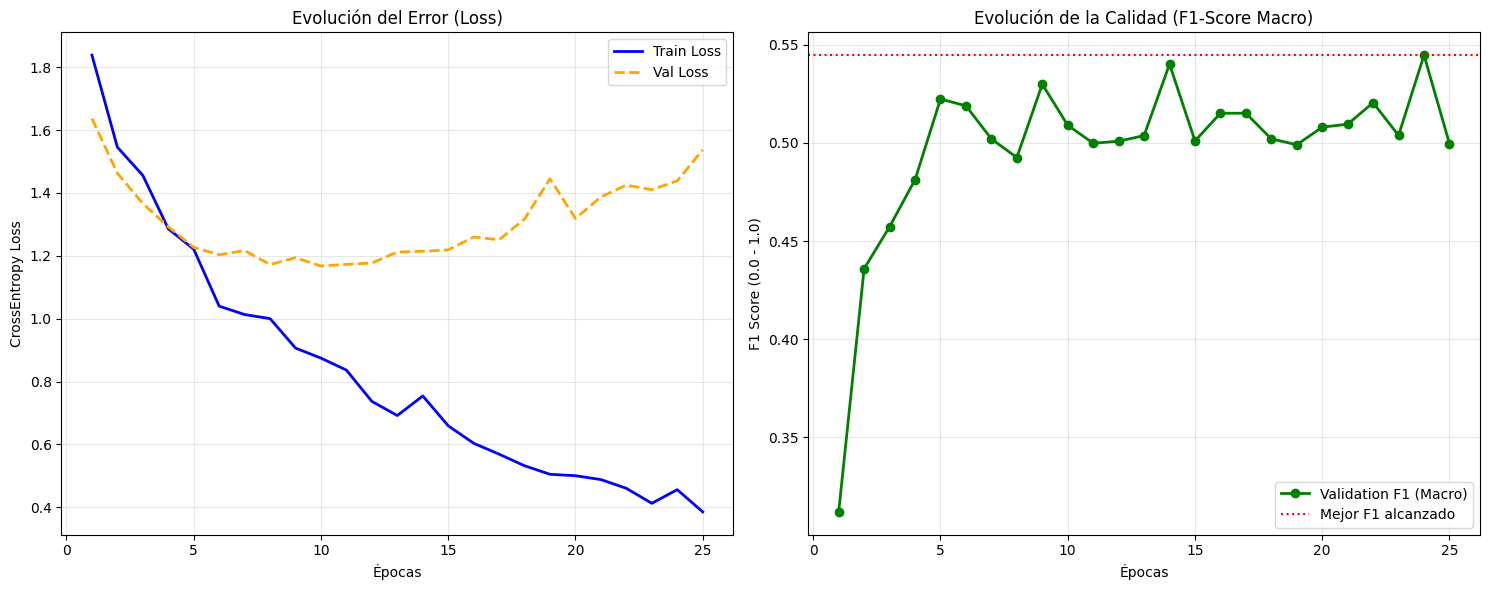


🎯 Resultados finales en TEST SET (Datos nunca vistos)

🔎 Analizando métricas detalladas para: TEST - DenseNet121_MedicalExpert...


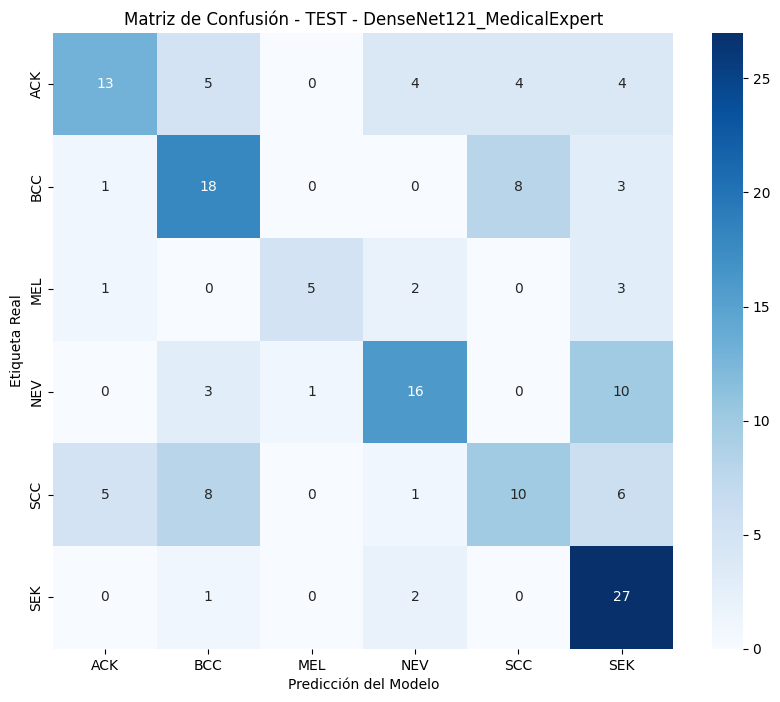


📋 REPORTE CLÍNICO DETALLADO (TEST - DenseNet121_MedicalExpert)
              precision    recall  f1-score   support

         ACK       0.65      0.43      0.52        30
         BCC       0.51      0.60      0.55        30
         MEL       0.83      0.45      0.59        11
         NEV       0.64      0.53      0.58        30
         SCC       0.45      0.33      0.38        30
         SEK       0.51      0.90      0.65        30

    accuracy                           0.55       161
   macro avg       0.60      0.54      0.55       161
weighted avg       0.57      0.55      0.54       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.5528 (Cuidado, dataset desbalanceado)
⚖️  Cohen's Kappa:     0.4533 (Grado de acuerdo real vs azar)


In [35]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# ==========================================
# 1. CARGAR DENSENET-121
# ==========================================
print("🔄 Cargando DenseNet-121 (El especialista médico)...")
weights = models.DenseNet121_Weights.DEFAULT
model = models.densenet121(weights=weights)

# ==========================================
# 2. ESTRATEGIA DE CONGELADO (Smart Freezing)
# ==========================================
# Paso A: Congelar todo el extractor de características ('features')
for param in model.features.parameters():
    param.requires_grad = False

# Paso B: DESCONGELAR el último "Dense Block"
# DenseNet tiene una estructura: [denseblock1, trans1, denseblock2, ..., denseblock4, norm5]
# 'denseblock4' es la parte final y más abstracta. Vamos a descongelarla.
# Nota: model.features es un contenedor Sequential. El bloque 4 suele estar hacia el final.
# Para simplificar y no buscar índices, descongelamos el último 20% de las capas features.
# O más fácil: Descongelamos el bloque 'denseblock4' explícitamente si accedemos por nombre,
# pero por índice en features, suele ser features.denseblock4. 
# En la implementación de torchvision, se puede acceder por atributos.

for param in model.features.denseblock4.parameters():
    param.requires_grad = True
    
# También descongelamos la norma final para que se adapte
for param in model.features.norm5.parameters():
    param.requires_grad = True

# ==========================================
# 3. ADAPTAR LA CABEZA (Classifier)
# ==========================================
num_ftrs = model.classifier.in_features
num_classes = len(train_loader.dataset.classes)

model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)

model = model.to(device)

# ==========================================
# 4. OPTIMIZADOR DIFERENCIAL
# ==========================================
optimizer_ft = optim.AdamW([
    {'params': model.features.denseblock4.parameters(), 'lr': 1e-4}, # Ajuste fino del cuerpo
    {'params': model.features.norm5.parameters(), 'lr': 1e-4},       # Ajuste fino de la norma
    {'params': model.classifier.parameters(), 'lr': 1e-3}            # Aprendizaje rápido de la cabeza
], weight_decay=0.01)

# ==========================================
# 5. LANZAR EXPERIMENTO
# ==========================================
model_entrenado = lanzar_experimento(
    modelo=model,
    nombre_exp="DenseNet121_MedicalExpert",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    optimizer_ft=optimizer_ft 
)

In [42]:
from ultralytics import YOLO
import os

# 1. Definir la ruta a TUS datos (Asegúrate de haber renombrado 'validation' a 'val')
# Usa ruta absoluta si quieres evitar problemas, o relativa si sabes dónde estás.
dataset_path = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT"

# 2. Cargar el modelo YOLO11x (Classification)
model = YOLO('yolo11x-cls.pt')  # Se descarga solo la primera vez

print(f"🚀 Lanzando entrenamiento con datos en: {dataset_path}")

# 3. Entrenar
results = model.train(
    data=dataset_path,  # <--- Apunta directamente a tu carpeta existente
    epochs=25,
    imgsz=224,
    batch=16,           # Si te da error de memoria (CUDA OOM), baja a 8
    patience=5,         # Early stopping
    project='SkinCancer_Project',
    name='YOLO11x_Run',
    lr0=0.0001,
    optimizer='AdamW'
)

🚀 Lanzando entrenamiento con datos en: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT
Ultralytics 8.4.7 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6371.9±1634.9 MB/s, size: 1837.7 KB)
train: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT/train... 512 images, 0 corrupt: 100% ━━━━━━━━━━━━ 512/512 304.1it/s 1.7s0.1s
train: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2213.3±2216.3 MB/s, size: 1350.9 KB)
val: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT/val... 129 images, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 147.9it/s 0.9s0.1s
val: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT/val.cache
optimizer: AdamW(lr=0.0001, momentum=0.937) with parameter groups 82 weight(decay=0.0), 8

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

       1/25      1.97G      1.674         16        224: 100% ━━━━━━━━━━━━ 32/32 5.8it/s 5.5s<0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 7.6it/s 0.7s0.1s
                   all      0.372      0.953

      Epoch    GPU_mem       loss  Instances       Size
       2/25       2.1G      1.376         16        224: 0% ──────────── 0/32  0.1s

...

      14/25      4.08G     0.5413         16        224: 100% ━━━━━━━━━━━━ 32/32 12.1it/s 2.6s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 31.6it/s 0.2s.2s
                   all      0.535      0.992

      Epoch    GPU_mem       loss  Instances       Size
      15/25      2.15G      0.456         16        224: 3% ──────────── 1/32 1.8it/s 0.2s<17.3s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      15/25      2.15G     0.5112         16        224: 100% ━━━━━━━━━━━━ 32/32 12.2it/s 2.6s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 27.6it/s 0.2s.2s
                   all       0.55      0.992

      Epoch    GPU_mem       loss  Instances       Size
      16/25      2.15G     0.5877         16        224: 0% ──────────── 0/32  1.0s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      16/25      2.29G     0.4797         16        224: 100% ━━━━━━━━━━━━ 32/32 8.2it/s 3.9s<0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 27.7it/s 0.2s.2s
                   all      0.566      0.992
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 11, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

16 epochs completed in 0.018 hours.
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/runs/classify/SkinCancer_Project/YOLO11x_Run3/weights/last.pt, 57.0MB
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/runs/classify/SkinCancer_Project/YOLO11x_Run3/weights/best.pt, 57.0MB

Validating /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and

🔄 Cargando modelo YOLO desde: ../DAVID/runs/classify/SkinCancer_Project/YOLO11x_Run3/weights/best.pt
🔎 Analizando métricas en TEST SET: ../Datos/images/DATASET_SPLIT/test ...


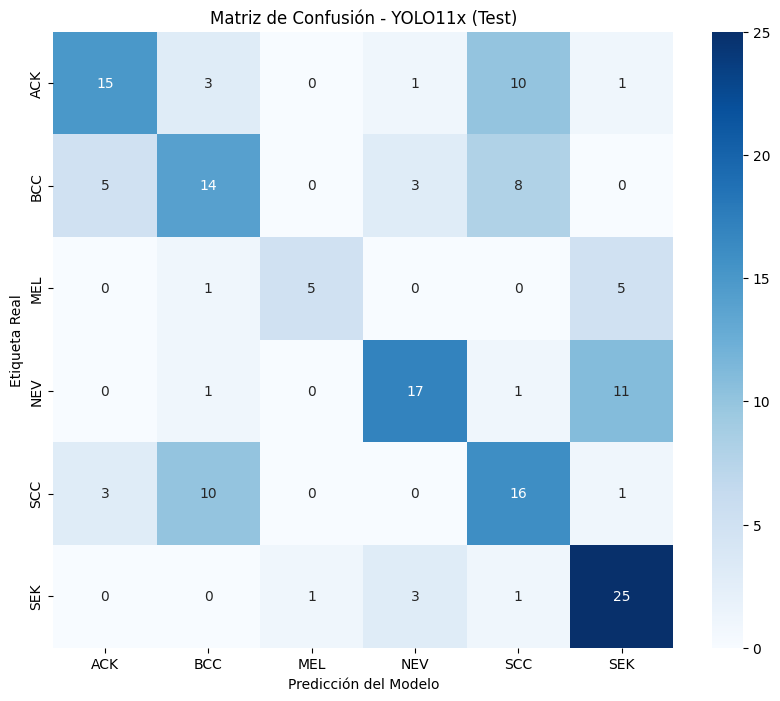


📋 REPORTE CLÍNICO DETALLADO (YOLO11x)
              precision    recall  f1-score   support

         ACK       0.65      0.50      0.57        30
         BCC       0.48      0.47      0.47        30
         MEL       0.83      0.45      0.59        11
         NEV       0.71      0.57      0.63        30
         SCC       0.44      0.53      0.48        30
         SEK       0.58      0.83      0.68        30

    accuracy                           0.57       161
   macro avg       0.62      0.56      0.57       161
weighted avg       0.59      0.57      0.57       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.5714
⚖️  Cohen's Kappa:    0.4761


In [46]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score
from ultralytics import YOLO

def evaluar_yolo_clinico(ruta_modelo, carpeta_test):
    """
    Replica la evaluación clínica detallada para modelos YOLO.
    Genera:
    1. Matriz de Confusión (Seaborn heatmap).
    2. Reporte de Clasificación (Precision, Recall, F1).
    3. Métricas Globales (Accuracy, Kappa).
    """
    
    print(f"🔄 Cargando modelo YOLO desde: {ruta_modelo}")
    model = YOLO(ruta_modelo)
    
    print(f"🔎 Analizando métricas en TEST SET: {carpeta_test} ...")
    
    y_true = []
    y_pred = []
    
    # Mapeo inverso: Nombre Clase -> Índice (Ej: 'MEL' -> 0)
    # YOLO guarda los nombres en model.names {0: 'ACK', 1: 'BCC'...}
    name_to_idx = {v: k for k, v in model.names.items()}
    
    # Recorremos la carpeta de TEST imagen por imagen
    # Estructura esperada: carpeta_test/CLASE/imagen.jpg
    
    # Obtenemos las clases ordenadas por índice para que la matriz salga bien
    sorted_indices = sorted(model.names.keys())
    class_names = [model.names[i] for i in sorted_indices]
    
    # Iteramos sobre las carpetas de clase
    for cls_name in os.listdir(carpeta_test):
        cls_path = os.path.join(carpeta_test, cls_name)
        
        # Ignoramos archivos sueltos, solo queremos carpetas
        if not os.path.isdir(cls_path):
            continue
            
        if cls_name not in name_to_idx:
            print(f"⚠️ Advertencia: La carpeta '{cls_name}' no es una clase conocida por el modelo.")
            continue
            
        true_idx = name_to_idx[cls_name]
        
        # Iteramos sobre las imágenes dentro de la clase
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for file in files:
            img_path = os.path.join(cls_path, file)
            
            # --- PREDICCIÓN YOLO ---
            # verbose=False para que no llene la pantalla de logs
            results = model(img_path, verbose=False)
            
            # Extraemos la clase con mayor probabilidad (Top-1)
            pred_idx = results[0].probs.top1
            
            y_true.append(true_idx)
            y_pred.append(pred_idx)
            
    # --- 1. MATRIZ DE CONFUSIÓN VISUAL ---
    cm = confusion_matrix(y_true, y_pred, labels=sorted_indices)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - YOLO11x (Test)')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    
    # --- 2. REPORTES NUMÉRICOS ---
    print(f"\n📋 REPORTE CLÍNICO DETALLADO (YOLO11x)")
    print("="*70)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("-" * 70)
    
    # Métricas Globales
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    print(f"✅ Accuracy Global:   {acc:.4f}")
    print(f"⚖️  Cohen's Kappa:    {kappa:.4f}")
    print("="*70)

# --- EJECUCIÓN ---
# Ajusta las rutas si es necesario
ruta_pesos = '../DAVID/runs/classify/SkinCancer_Project/YOLO11x_Run3/weights/best.pt'
ruta_test = '../Datos/images/DATASET_SPLIT/test'

evaluar_yolo_clinico(ruta_pesos, ruta_test)

📋 Clases detectadas: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
🔄 Cargando Modelos PyTorch...
✅ PyTorch Models Loaded.
🔄 Cargando Modelo YOLO...
✅ YOLO Loaded.

🚀 Iniciando Inferencia Ensemble en 6 clases...

🏆 RESULTADOS DEL ENSEMBLE (RESNET + DENSENET + YOLO)
              precision    recall  f1-score   support

         ACK       0.59      0.43      0.50        30
         BCC       0.52      0.57      0.54        30
         MEL       0.83      0.45      0.59        11
         NEV       0.79      0.77      0.78        30
         SCC       0.45      0.47      0.46        30
         SEK       0.68      0.90      0.77        30

    accuracy                           0.61       161
   macro avg       0.64      0.60      0.61       161
weighted avg       0.62      0.61      0.61       161



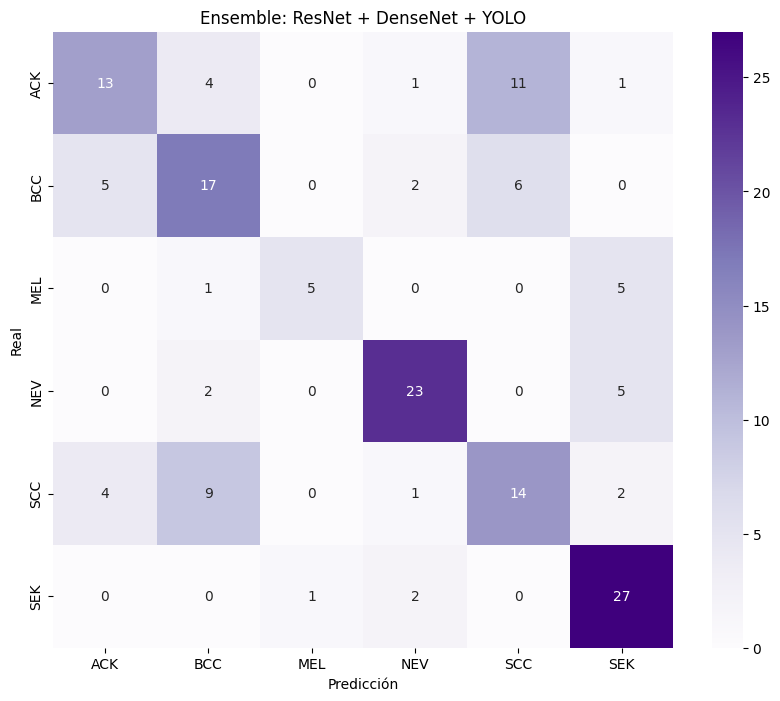

✅ Accuracy Global Ensemble: 0.6149


In [63]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from ultralytics import YOLO
from PIL import Image
import os
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
carpeta_test = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT/test"

# RUTAS DE LOS PESOS (¡AJÚSTALAS!)
ruta_resnet = "ResNet18_Baseline_best.pth"       # Pon tu ruta real
ruta_densenet = "DenseNet121_MedicalExpert_best.pth" # Pon tu ruta real
ruta_yolo = "../DAVID/runs/classify/SkinCancer_Project/YOLO11x_Run3/weights/best.pt" # Pon tu ruta real

# Clases en orden alfabético (Es el estándar de ImageFolder)
clases = sorted(os.listdir(carpeta_test))
print(f"📋 Clases detectadas: {clases}")

# ==========================================
# 2. CARGAR MODELOS PYTORCH (ResNet + DenseNet)
# ==========================================
def cargar_resnet(path, num_classes):
    model = models.resnet18(weights=None) # No descargamos pesos, cargamos los tuyos
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features, num_classes))
    # Cargar state_dict con seguridad
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    return model

def cargar_densenet(path, num_classes):
    model = models.densenet121(weights=None)
    # Reconstruir la cabeza exactamente como la entrenaste
    model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.classifier.in_features, num_classes))
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    return model

print("🔄 Cargando Modelos PyTorch...")
try:
    model_res = cargar_resnet(ruta_resnet, len(clases))
    model_dense = cargar_densenet(ruta_densenet, len(clases))
    print("✅ PyTorch Models Loaded.")
except FileNotFoundError:
    print("❌ ERROR: No encuentro los .pth de ResNet o DenseNet. Revisa las rutas.")

# Preprocesamiento PyTorch (Debe ser idéntico al del entrenamiento)
transform_pt = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ==========================================
# 3. CARGAR MODELO YOLO
# ==========================================
print("🔄 Cargando Modelo YOLO...")
model_yolo = YOLO(ruta_yolo)
print("✅ YOLO Loaded.")

# ==========================================
# 4. BUCLE DE INFERENCIA (ENSEMBLE)
# ==========================================
y_true = []
y_pred_ensemble = []

print(f"\n🚀 Iniciando Inferencia Ensemble en {len(clases)} clases...")

# Iterar carpetas
for idx_clase, nombre_clase in enumerate(clases):
    ruta_clase = os.path.join(carpeta_test, nombre_clase)
    if not os.path.isdir(ruta_clase): continue
    
    imagenes = [f for f in os.listdir(ruta_clase) if f.lower().endswith(('.jpg', '.png'))]
    
    for img_name in imagenes:
        img_path = os.path.join(ruta_clase, img_name)
        
        # --- PREDICCIÓN 1: PYTORCH (ResNet) ---
        img_pil = Image.open(img_path).convert('RGB')
        img_tensor = transform_pt(img_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            # ResNet
            logits_res = model_res(img_tensor)
            probs_res = F.softmax(logits_res, dim=1).cpu().numpy()[0]
            
            # DenseNet
            logits_dense = model_dense(img_tensor)
            probs_dense = F.softmax(logits_dense, dim=1).cpu().numpy()[0]
            
        # --- PREDICCIÓN 2: YOLO ---
        # YOLO devuelve un objeto Results
        res_yolo = model_yolo(img_path, verbose=False)[0]
        
        # OJO: YOLO puede tener los índices desordenados. Mapeamos por nombre.
        probs_yolo = np.zeros(len(clases))
        for cls_idx_yolo, conf in enumerate(res_yolo.probs.data.cpu().numpy()):
            # Nombre de la clase según YOLO
            nombre_yolo = res_yolo.names[cls_idx_yolo]
            # Buscamos dónde está ese nombre en nuestra lista 'clases' ordenada alfabéticamente
            if nombre_yolo in clases:
                idx_real = clases.index(nombre_yolo)
                probs_yolo[idx_real] = conf
        
        # --- FUSIÓN (AVERAGE VOTING) ---
        # Puedes dar más peso a YOLO si quieres: (res + dense + 2*yolo) / 4
        probs_final = (0.3*probs_res + 0.2*probs_dense + 0.5*probs_yolo)
        
        pred_final = np.argmax(probs_final)
        
        y_true.append(idx_clase)
        y_pred_ensemble.append(pred_final)

# ==========================================
# 5. RESULTADOS
# ==========================================
print("\n🏆 RESULTADOS DEL ENSEMBLE (RESNET + DENSENET + YOLO)")
print("="*60)
print(classification_report(y_true, y_pred_ensemble, target_names=clases, zero_division=0))

# Matriz
cm = confusion_matrix(y_true, y_pred_ensemble)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=clases, yticklabels=clases)
plt.title("Ensemble: ResNet + DenseNet + YOLO")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

acc = accuracy_score(y_true, y_pred_ensemble)
print(f"✅ Accuracy Global Ensemble: {acc:.4f}")